In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]   # move up from notebooks/
sys.path.insert(0, str(PROJECT_ROOT))
from data import SequenceProcessingPipeline
import torch
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
data_name = 'IEDB_Jespersen'
model_name = 'esmc_300m'
base_data_dir = Path.cwd().parents[0]  / 'data'/ 'data_files'
pipe = SequenceProcessingPipeline(
        data_name=data_name,
        model_name=model_name,
        sequence_kind="single",
        save_dir=base_data_dir,
)

dataset = pipe.build_training_dataset(
        storage="lmdb",
        representation="hidden_states",
        hidden_layers=10,
)


In [4]:
full_data = np.concatenate([dataset[i][0].numpy() for i in range(1000)], axis=0)
full_scaler = StandardScaler()
full_pca = PCA(n_components=4).fit(full_scaler.fit_transform(full_data))

PCA(n_components=4)

In [5]:

def plot_pcas(idx, pc1=0, pc2=1, pc3=2):
    x, y = dataset[idx]
    single_pca = PCA(n_components=4)
    single_scaler = StandardScaler()
    single_transform = single_pca.fit_transform(single_scaler.fit_transform(x))
    batch_transform = full_pca.transform(full_scaler.transform(x))
    ln_pca = PCA(n_components=4)
    ln_data = (x - x.mean(-1, keepdims=True)) - x.std(-1, keepdims=True)
    ln_transform = ln_pca.fit_transform(ln_data)

    fig, axs = plt.subplots(2, 3, figsize=(10, 5))
    axs[0, 0].set_title('Single Transform')
    axs[0, 0].scatter(single_transform[:, pc1], single_transform[:, pc2], c=y.numpy(), cmap=plt.get_cmap('jet'))
    axs[1, 0].scatter(single_transform[:, pc2], single_transform[:, pc3], c=y.numpy(), cmap=plt.get_cmap('jet'))

    axs[0, 1].set_title('Batch Transform')
    axs[0, 1].scatter(batch_transform[:, pc1], batch_transform[:, pc2], c=y.numpy(), cmap=plt.get_cmap('jet'))
    axs[1, 1].scatter(batch_transform[:, pc2], batch_transform[:, pc3], c=y.numpy(), cmap=plt.get_cmap('jet'))

    axs[0, 2].set_title('Layer Norm Transform')
    axs[0, 2].scatter(ln_transform[:, pc1], ln_transform[:, pc2], c=y.numpy(), cmap=plt.get_cmap('jet'))
    axs[1, 2].scatter(ln_transform[:, pc2], ln_transform[:, pc3], c=y.numpy(), cmap=plt.get_cmap('jet'))



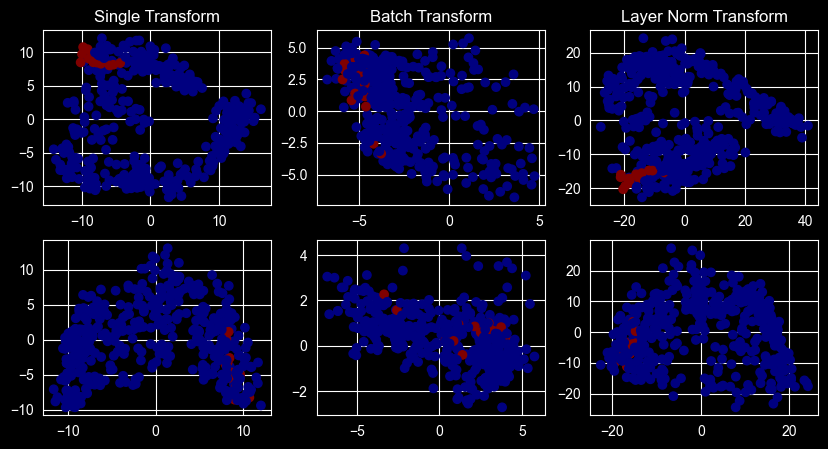

In [6]:
plot_pcas(1)

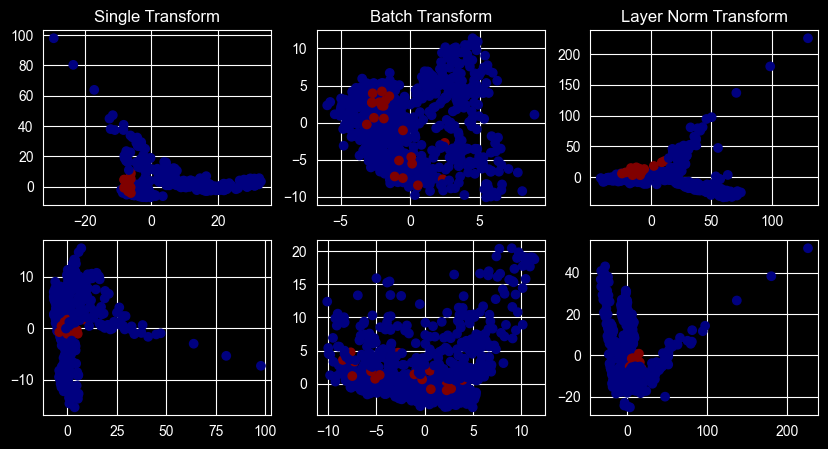

In [7]:
plot_pcas(2)

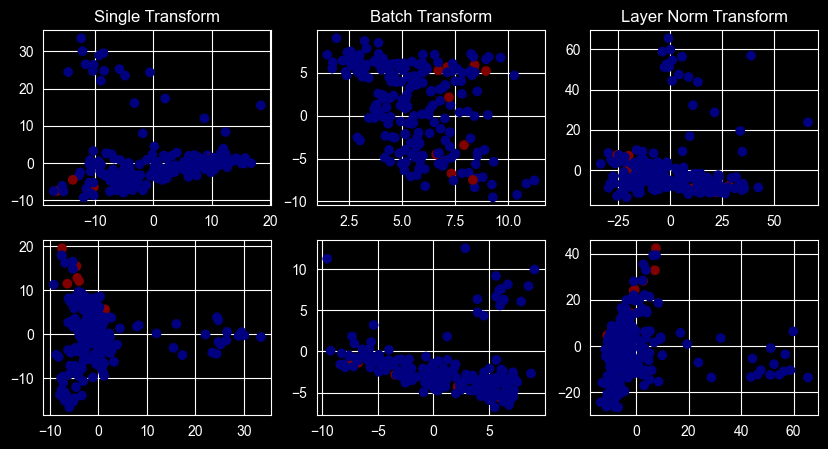

In [9]:
plot_pcas(4)

In [ ]:
kmeans = KMeans(n_clusters=20, n_init=10)
transformed = full_pca.transform(full_data)
clusters = kmeans.fit_predict(transformed)


In [ ]:
for c in np.unique(clusters):
    mask = clusters == c
    frac = full_labels[mask].mean()
    print(c, frac)